# 08 — D8 `hmm_tstudent` (HMM con emisiones t-Student · familia F3)

**HMM avanzado de colas pesadas.** Sustituye la gaussiana de cada estado del HMM puente
(D4) por una **t-Student multivariante** (location m_i, matriz de escala S_i y **grados de
libertad ν_i por estado**). La t tiene **colas pesadas** (kurtosis 25-40 del EDA): cada
estado absorbe saltos extremos sin inflar la varianza ni robar observaciones al estado de
crisis. Estimación por **EM con la variable de escala latente** (la t como mezcla de escala
gaussiana; ver `detectors/_hmm_t_utils.StudentTHMM`), inicializada de forma robusta desde un
**GaussianHMM** (varias semillas, mayor logL) y refinada con EM-t.

**t-Student, NO GMM-HMM — por qué.** El CHECKPOINT 2 contempló *"HMM t-Student o GMM-HMM"*.
Se usa la **t-Student propia** por dos razones: (1) **BIC justo** — la t añade solo **k**
parámetros (un ν por estado) sobre el HMM gaussiano equivalente, mientras que un GMM-HMM
multiplica medias/covarianzas por la mezcla y dispara el BIC; (2) **robustez** — sin
componentes de mezcla que colapsen, con arranque gaussiano estable.

**K por BIC sobre {3, 4}.** D5 ya mostró que el BIC prefiere k=3 sobre k=2; aquí elegimos el
mejor entre **3 y 4**. Con K≥3 el orden económico es **calma → corrección → crisis**
(severidad creciente en volatilidad).

**Causalidad — FILTRADO FORWARD t (no Viterbi intra-bloque).** En walk-forward,
`predict_online`/`predict_proba` usan el filtrado forward t (`filtered_posterior_t`) con
burn-in de train: la etiqueta/prob de t usa SOLO obs ≤ t. Viterbi t solo IN-SAMPLE, marcado.

**Features/ventana = D4** (las 7 puente, ventana 2007+, `train_size=252*5`): así el BIC de
D8 (t) es comparable con el de D4 (gaussiano) sobre los mismos datos; 2008/2011 caen en train
(coberturas NaN OOS), igual que D4.

**Hipótesis CHECKPOINT 2 (D8):** *emisiones t + más estados atacan las fat tails y
POTENCIALMENTE captan 2013/2018 donde el gaussiano falla; riesgo de sobreajuste con pocas
observaciones por estado.* Se verifica al final.

## Índice navegable

| # | Sección | Figura |
|---|---------|--------|
| 1 | [Selección de K por BIC sobre {3, 4}](#s1) | — |
| 2 | [Detector desplegado: parámetros por estado y monotonía in-sample](#s2) | — |
| 3 | [Espacio de las 7 features puente (PCA 2D) por estado](#s3) | **`d08_feature_scatter.png`** *(nueva)* |
| 4 | [Colas t-Student vs Gaussiana — por qué la t capta los días extremos](#s4) | **`d08_t_vs_gaussian_tails.png`** *(nueva)* |
| 5 | [Walk-forward causal (filtrado forward t)](#s5) | — |
| 6 | [Evaluación estandarizada y fila de métricas (32 columnas)](#s6) | — |
| 7 | [Verificación de monotonía en walk-forward](#s7) | — |
| 8 | [Severidad monótona por estado en walk-forward](#s8) | **`d08_state_severity.png`** *(nueva)* |
| 9 | [S&P 500 coloreado por los K estados (OOS)](#s9) | `d8_tstudent_sp500_regimes.png` |
| 10 | [Probabilidad filtrada de crisis (causal, OOS)](#s10) | `d8_tstudent_crisis_proba.png` |
| 11 | [Matriz de transición (persistencia de regímenes)](#s11) | `d8_tstudent_transition.png` |
| 12 | [Verificación contra crisis y trampas — ¿captó 2013/2018?](#s12) | — |
| 13 | [BIC vs D4 — ¿la t mejora el ajuste pese a más parámetros?](#s13) | `d8_tstudent_bic_vs_d4.png` |
| 14 | [Conclusión y contraste con la hipótesis del CHECKPOINT 2](#s14) | — |

**Mapa de lectura.** Las secciones **3, 4 y 8** son las añadidas en esta revisión (figuras
nuevas `d08_*`); el resto **preserva** la verificación causal, la comparación BIC vs D4, la
estructura *Hipótesis CP2 → veredicto* y el volcado de métricas (32 columnas) originales. El
notebook separa de forma deliberada **dos problemas distintos**: (i) el **problema
distribucional** —las colas pesadas de los retornos— que la t-Student SÍ resuelve (§3–§4, §8,
§13); y (ii) el **problema de cobertura del espacio de features** en 2013/2018 —una limitación
de las 7 features puente, NO de la familia de emisión— que la t NO puede resolver (§12). Esta
distinción es el núcleo de la conclusión (§14).

In [1]:
%matplotlib inline
import sys, warnings, logging
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')
logging.getLogger('hmmlearn').setLevel(logging.CRITICAL)

ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'; RESULTS.mkdir(exist_ok=True)
from src import evaluation as ev
from src import viz                       # helpers de visualización de casa (paleta consistente)
from detectors.hmm_tstudent import HMMTStudent
from detectors.hmm_gaussian_2s import BRIDGE_FEATURES
viz.use_house_style()                     # rcParams homogéneos (fuentes, grid, DPI)

feats = pd.read_parquet(ROOT / 'data' / 'processed' / 'features.parquet')
raw   = pd.read_parquet(ROOT / 'data' / 'raw' / 'raw_panel.parquet')
X = feats[BRIDGE_FEATURES].copy()
mkt = np.log(raw['SP500'] / raw['SP500'].shift(1)).reindex(X.index)   # market_returns S&P 500
spx = raw['SP500'].reindex(X.index)
print('Features puente (7):', BRIDGE_FEATURES)
print('Ventana:', X.index.min().date(), '->', X.index.max().date(), '| n =', len(X))

Features puente (7): ['SP500_ret_z', 'TLT_ret_z', 'IEF_ret_z', 'HYG_ret_z', 'SP500_vol_z', 'credit_spread_z', 'VIX_level_z']
Ventana: 2007-07-06 -> 2026-06-12 | n = 4665


## <a id="s1"></a>1. Selección de K por BIC sobre {3, 4} (comparable con D4)

Ajustamos el HMM-t con **k=3** y **k=4** sobre toda la ventana puente y comparamos
logL/AIC/BIC. La t añade solo `k` parámetros (un ν por estado) sobre el HMM gaussiano
equivalente, así que el BIC es directamente comparable con el de D4 (k=2 gaussiano).
Desplegamos el K de **menor BIC**.

In [2]:
rows, fits = [], {}
for k in (3, 4):
    d = HMMTStudent(n_states=k, n_init=4, t_n_iter=30).fit(X)
    d.label_states_economically(X, market_returns=mkt)
    fits[k] = d
    rows.append({'k': k, 'logL': d.score(X), 'n_params': d.n_parameters(),
                 'AIC': d.aic(X), 'BIC': d.bic(X)})
sel = pd.DataFrame(rows).set_index('k')
print(sel.round(1))
K = int(sel['BIC'].idxmin())
bic_K = float(sel.loc[K, 'BIC']); aic_K = int(sel['AIC'].idxmin())
print(f'\nK* por BIC = {K}  (BIC={bic_K:.1f})  | por AIC = {aic_K}')
print('grados de libertad nu por estado (canónico) para cada k:')
for k in (3, 4):
    print(f'  k={k}: ν =', np.round(fits[k].dofs_canonical(), 2))

      logL  n_params      AIC      BIC
k                                     
3 -13561.5       116  27355.1  28103.0
4 -11536.3       159  23390.7  24415.9

K* por BIC = 4  (BIC=24415.9)  | por AIC = 4
grados de libertad nu por estado (canónico) para cada k:
  k=3: ν = [9.01 8.05 3.28]
  k=4: ν = [10.21  7.62  4.15  2.38]


## <a id="s2"></a>2. Detector desplegado (K* por BIC): parámetros por estado y monotonía IN-SAMPLE

Verificamos el **orden económico monótono en severidad**: media y vol del retorno por
estado canónico (0=calma … K-1=crisis). Con K≥3 el binning por bandas de vol del núcleo
(`VOL_CLOSE_FRAC`) debe dar **vol creciente** 0→K-1 (severidad monótona), no solo
'crisis=peor'. También mostramos ν por estado (el de crisis debe tener ν menor = colas más
pesadas).

In [3]:
det = fits[K]
print('Detector:', det.name, '| crisis_state canónico =', det.crisis_state, '| K =', det.n_states)
print('bibliografía:', det.bibliography)
st_is = pd.Series(det.predict(X), index=X.index)   # Viterbi t IN-SAMPLE (no causal)
nu_c = det.dofs_canonical()
print('\n--- Parámetros por estado (orden canónico 0=calma .. K-1=crisis) ---')
rmean, rvol = [], []
for s in range(det.n_states):
    r = mkt[st_is == s]
    rmean.append(r.mean()*252); rvol.append(r.std()*np.sqrt(252))
    tag = 'CRISIS' if s == det.crisis_state else ('calma ' if s == 0 else 'corrección')
    print(f'  estado {s} [{tag:9s}]: ret_ann={rmean[-1]:+7.2%} | vol_ann={rvol[-1]:6.2%} | ν={nu_c[s]:5.2f} | n={len(r)}')
mono_vol_is = all(rvol[i] < rvol[i+1] for i in range(len(rvol)-1))
print('\nVERIFICACIÓN monotonía de VOL (severidad creciente) IN-SAMPLE:', mono_vol_is)
assert mono_vol_is, 'FALLO: la vol por estado NO es monótona creciente in-sample'
ST_LABELS = (['calma', 'corrección', 'crisis'] if det.n_states == 3
             else ['calma', 'leve', 'corrección', 'crisis'])

Detector: hmm_tstudent_4s | crisis_state canónico = 3 | K = 4
bibliografía: ['hamilton1989', 'hmm_rabiner1989', 'hmm_bulla2011', 'guidolintimmermann2007']

--- Parámetros por estado (orden canónico 0=calma .. K-1=crisis) ---
  estado 0 [calma    ]: ret_ann=+24.02% | vol_ann= 8.11% | ν=10.21 | n=1357
  estado 1 [corrección]: ret_ann=+12.80% | vol_ann=12.57% | ν= 7.62 | n=1306
  estado 2 [corrección]: ret_ann= -7.60% | vol_ann=22.71% | ν= 4.15 | n=1282
  estado 3 [CRISIS   ]: ret_ann= -8.11% | vol_ann=35.10% | ν= 2.38 | n=720

VERIFICACIÓN monotonía de VOL (severidad creciente) IN-SAMPLE: True


## <a id="s3"></a>3. Espacio de las 7 features puente (PCA 2D) por estado · *figura nueva*

Antes de medir la causalidad conviene **ver dónde** parte el HMM-t el espacio de features.
Proyectamos las **7 features puente** estandarizadas a 2 componentes principales (PCA) y
coloreamos cada día por su **estado canónico in-sample** (Viterbi t): verde→azul calma,
ámbar corrección, rojo crisis. La lectura es doble:

- **Separabilidad de los 4 regímenes.** Si las cuatro nubes ocupan regiones distintas del
  plano PCA, el HMM-t encuentra estructura real (no trocea el espacio al azar). Se espera un
  *gradiente de severidad* a lo largo del eje de mayor varianza: la nube de crisis (rojo) en
  la cola de alta volatilidad / *risk-off*, la de calma (azul) en el núcleo denso.
- **Por qué hace falta la t.** Esos puntos de la cola roja son precisamente los **días
  extremos** (kurtosis 25–40 del EDA). Con emisiones gaussianas, un único estado debe
  *estirar* su covarianza para cubrirlos e infla su varianza; la t-Student los absorbe con
  sus **colas pesadas** sin contaminar la escala del estado (esto se cuantifica en §4).

**Matiz importante (cobertura de features).** El PCA solo refleja la información contenida en
estas 7 features. Si un episodio como el *taper tantrum* de 2013 no deja huella suficiente en
ellas, **ningún** modelo de emisión —gaussiano o t— podrá separarlo aquí: es el *problema de
cobertura* de §12, distinto del *problema distribucional* que resuelve la t.

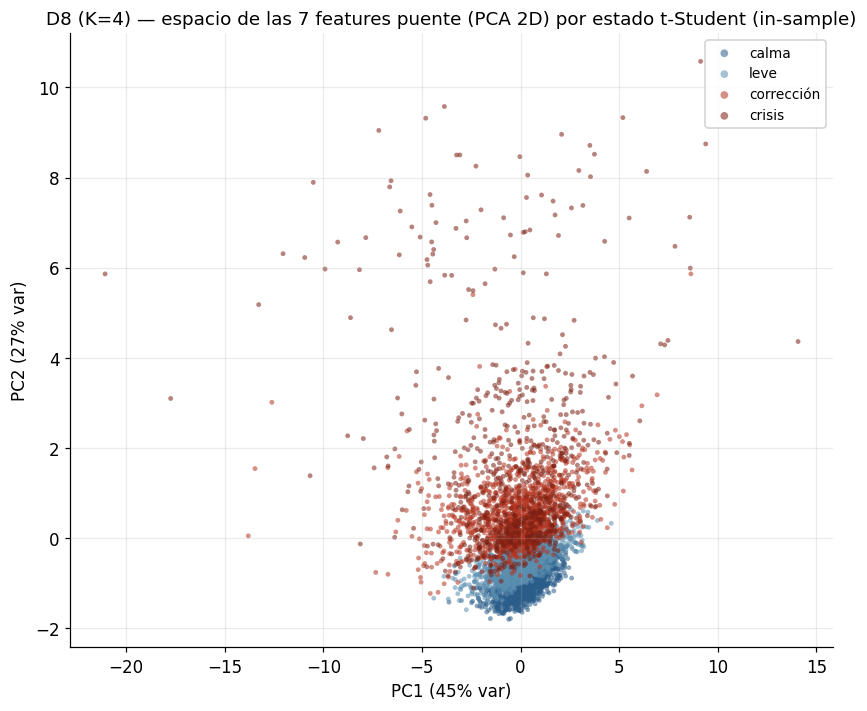

Lectura: azul=calma .. rojo=crisis. El gradiente de color a lo largo de PC1 (eje de
mayor varianza) indica que el HMM-t ordena los estados por severidad en el propio
espacio de features. La cola roja = días extremos que motivan las emisiones t (ver §4).


In [4]:
fig, ax = plt.subplots(figsize=(7.8, 6.6))
viz.plot_feature_space_scatter(
    X, st_is, use_pca=True, crisis_state=det.crisis_state, labels=ST_LABELS, ax=ax,
    title=f'D8 (K={K}) — espacio de las 7 features puente (PCA 2D) por estado t-Student (in-sample)')
fig.tight_layout()
fig.savefig(RESULTS / 'd08_feature_scatter.png', dpi=110, bbox_inches='tight'); plt.show()
print('Lectura: azul=calma .. rojo=crisis. El gradiente de color a lo largo de PC1 (eje de')
print('mayor varianza) indica que el HMM-t ordena los estados por severidad en el propio')
print('espacio de features. La cola roja = días extremos que motivan las emisiones t (ver §4).')

## <a id="s4"></a>4. Colas t-Student vs Gaussiana — por qué la t capta los días extremos · *figura nueva*

Esta figura es el **corazón mecánico de D8**: ilustra *por qué* las emisiones t-Student capturan
los días de cola que el gaussiano no puede. Tomamos el **estado de crisis** y, dentro de él,
la **feature más leptocúrtica** (la de mayor kurtosis condicional al estado). Sobre el
histograma empírico de esa feature superponemos:

- la **densidad t marginal ajustada** por el HMM (location m, escala √S_jj, **mismos ν** del
  estado — propiedad de marginalización de la t multivariante), en rojo;
- una **gaussiana de la MISMA varianza** (línea negra discontinua).

En **escala logarítmica del eje y**, la diferencia salta a la vista: a igualdad de varianza, la
t pone **mucha más masa en las colas** (y un pico más alto en el centro), de modo que un salto
extremo de 5–8σ tiene probabilidad *finita y razonable* bajo la t pero *prácticamente nula*
bajo la gaussiana. El panel derecho resume los **grados de libertad ν por estado**: ν bajo =
colas más pesadas; se espera que el estado de **crisis** tenga el ν **menor** (mayor
leptocurtosis) y la **calma** un ν alto (≈ gaussiano), coherente con la severidad creciente.

feature elegida = HYG_ret_z  (kurtosis crisis=14.2) | ν_crisis=2.38


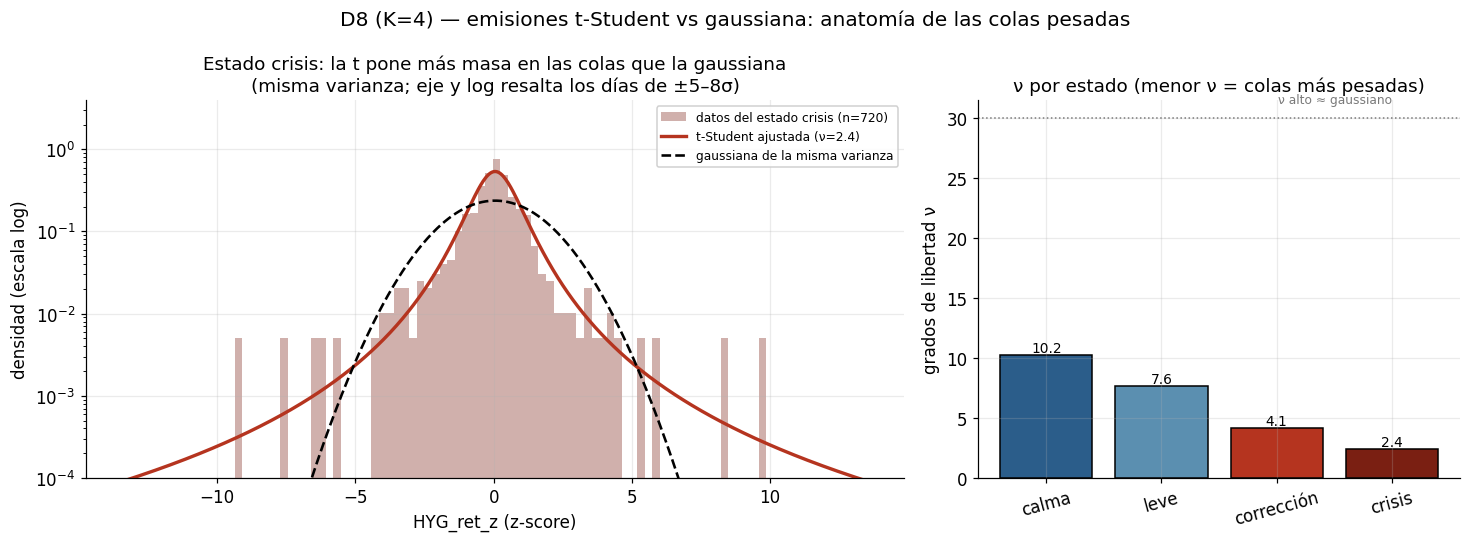

Lectura: a igualdad de varianza, la t (rojo) domina a la gaussiana (negra) en las colas.
Eso permite que UN solo estado de crisis absorba saltos extremos sin inflar su escala
ni robar observaciones a los estados calmados — el mecanismo central de D8.


In [5]:
from scipy import stats
order = det._canonical_order
means_c  = det._model.means_[order]
scales_c = det._model.scales_[order]
nu_c     = det.dofs_canonical()
cs = det.crisis_state
Xv = X[BRIDGE_FEATURES].values
mask_cri = (st_is.values == cs)
# feature mas leptocurtica DENTRO del estado de crisis (la que mas 'pide' colas pesadas)
kurts = [stats.kurtosis(Xv[mask_cri, j], fisher=True, nan_policy='omit') for j in range(len(BRIDGE_FEATURES))]
jf = int(np.nanargmax(kurts)); feat = BRIDGE_FEATURES[jf]
m_j  = float(means_c[cs, jf]); s_jj = float(scales_c[cs, jf, jf]); nu_j = float(nu_c[cs])
sigma = np.sqrt(s_jj * nu_j / (nu_j - 2.0)) if nu_j > 2.0 else np.sqrt(s_jj)   # var de la t = S_jj·ν/(ν-2)
print(f'feature elegida = {feat}  (kurtosis crisis={kurts[jf]:.1f}) | ν_crisis={nu_j:.2f}')

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13.5, 5.0), gridspec_kw={'width_ratios': [1.7, 1]})
xs = np.linspace(m_j - 8*sigma, m_j + 8*sigma, 600)
t_pdf = stats.t.pdf(xs, df=nu_j, loc=m_j, scale=np.sqrt(s_jj))
g_pdf = stats.norm.pdf(xs, loc=m_j, scale=sigma)
data_cri = Xv[mask_cri, jf]; data_cri = data_cri[np.isfinite(data_cri)]
axA.hist(data_cri, bins=70, density=True, color=viz.regime_color(cs, det.n_states),
         alpha=0.35, label=f'datos del estado crisis (n={len(data_cri)})')
axA.plot(xs, t_pdf, color=viz.C_CRISIS, lw=2.2, label=f't-Student ajustada (ν={nu_j:.1f})')
axA.plot(xs, g_pdf, color='black', ls='--', lw=1.7, label='gaussiana de la misma varianza')
axA.set_yscale('log'); axA.set_ylim(max(1e-4, np.nanmin(t_pdf[t_pdf > 0])*0.5), None)
axA.set_xlabel(f'{feat} (z-score)'); axA.set_ylabel('densidad (escala log)')
axA.set_title(f'Estado crisis: la t pone más masa en las colas que la gaussiana\n'
              f'(misma varianza; eje y log resalta los días de ±5–8σ)')
axA.legend(framealpha=0.9, fontsize=8)
# Panel B: nu por estado (colas pesadas por severidad)
bars = axB.bar(range(det.n_states), nu_c,
               color=[viz.regime_color(s, det.n_states) for s in range(det.n_states)],
               edgecolor='black')
for b, nu in zip(bars, nu_c):
    axB.text(b.get_x()+b.get_width()/2, b.get_height(), f'{nu:.1f}', ha='center', va='bottom', fontsize=9)
axB.set_xticks(range(det.n_states)); axB.set_xticklabels(ST_LABELS, rotation=15)
axB.set_ylabel('grados de libertad ν'); axB.set_title('ν por estado (menor ν = colas más pesadas)')
axB.axhline(30, color=viz.C_NEG, ls=':', lw=1.0)
axB.text(det.n_states-1, 31, 'ν alto ≈ gaussiano', ha='right', va='bottom', fontsize=8, color=viz.C_NEG)
fig.suptitle(f'D8 (K={K}) — emisiones t-Student vs gaussiana: anatomía de las colas pesadas')
fig.tight_layout()
fig.savefig(RESULTS / 'd08_t_vs_gaussian_tails.png', dpi=110, bbox_inches='tight'); plt.show()
print('Lectura: a igualdad de varianza, la t (rojo) domina a la gaussiana (negra) en las colas.')
print('Eso permite que UN solo estado de crisis absorba saltos extremos sin inflar su escala')
print('ni robar observaciones a los estados calmados — el mecanismo central de D8.')

## <a id="s5"></a>5. Walk-forward CAUSAL (filtrado forward t, cubre 2012→2026 OOS)

`ev.walk_forward` reentrena el HMM-t en ventanas **expanding** (train inicial `252*5`) y
predice el bloque de `step` días con **filtrado forward t** (parámetros congelados +
burn-in de train) ⇒ probabilidades FILTRADAS causales, sin look-ahead intra-bloque. Se pasa
`market_returns` para **re-fijar el orden económico en cada fold** (sin warning de fallback).

**Coste / step.** El EM-t es caro (Baum-Welch + actualización de ν por fold). Como D5
(step=63), subimos el `step` a **126** (refit ~semestral): el walk-forward tarda ~5 min en
vez de >20. Los regímenes son persistentes y el filtrado dentro del bloque sigue siendo
diario y causal, así que el refit semestral es adecuado.

In [6]:
TRAIN_SIZE = 252 * 5   # 2008 y 2011 quedan en train (NaN OOS), igual que D4
STEP = 126             # refit ~semestral (EM-t caro); declarado en la ficha
factory = lambda: HMMTStudent(n_states=K, n_init=3, t_n_iter=25)
panel = ev.walk_forward(factory, X, market_returns=mkt,
                        train_size=TRAIN_SIZE, step=STEP, expanding=True)
print('Panel OOS:', panel.shape, '|', panel.index.min().date(), '->', panel.index.max().date())
panel.head(3)

Panel OOS: (3405, 3) | 2012-07-20 -> 2026-06-12


,state,p_crisis,fold
date,,,
2012-07-20,0,6.112899e-10,0
2012-07-23,0,1.319182e-10,0
2012-07-24,0,7.276826e-10,0


## <a id="s6"></a>6. Evaluación estandarizada y fila de métricas (32 columnas)

`ev.evaluate` con `market_returns` (validación económica) y `X_full` (logL/AIC/BIC del K*).
Guardamos en `results/metrics_08_hmm_tstudent.csv`.

In [7]:
res = ev.evaluate(det, panel, market_returns=mkt.reindex(panel.index), X_full=X)
row = ev.results_table([res])
out_csv = RESULTS / 'metrics_08_hmm_tstudent.csv'
row.to_csv(out_csv, index=False)
print('ventana_eval:', res.extra['ventana_eval'])
print('retorno medio por estado canónico (OOS):',
      {k_: round(v, 5) for k_, v in res.extra['mean_return_by_state'].items()})
print('Guardado:', out_csv.name, '| columnas =', row.shape[1])
row.T

ventana_eval: 2012-07-20→2026-06-12 (n=3405)
retorno medio por estado canónico (OOS): {0: 0.00051, 1: 0.00038, 2: 0.00023, 3: 0.0014}
Guardado: metrics_08_hmm_tstudent.csv | columnas = 32


,0
detector,hmm_tstudent_4s
n_states,4
ventana_eval,2012-07-20→2026-06-12 (n=3405)
oos_start,2012-07-20
oos_end,2026-06-12
n_oos,3405
false_alarm_rate,0.518868
switching_rate,0.051982
mean_regime_duration,19.129213
label_stability,0.876837


## <a id="s7"></a>7. Verificación de monotonía EN WALK-FORWARD (con market_returns)

Requisito clave: el orden económico debe ser **monótono en severidad (VOL) sobre las
etiquetas OOS causales**, no solo in-sample. Calculamos media y **volatilidad** del retorno
por estado canónico en el panel walk-forward y confirmamos vol creciente 0→K-1. (La media
del retorno puede NO ser monótona: la t de colas pesadas es simétrica y el estado de crisis
captura saltos EXTREMOS en ambos sentidos —incl. rebotes violentos—, así que la severidad la
define la **volatilidad**, como en el núcleo `_economic_state_order`.)

In [8]:
states_oos = panel['state']
mr_oos = mkt.reindex(panel.index)
print('--- Retorno por estado canónico (OOS causal) ---')
vols = []
for s in range(det.n_states):
    r = mr_oos[states_oos == s]
    v = r.std()*np.sqrt(252); vols.append(v)
    tag = 'CRISIS' if s == det.crisis_state else ('calma ' if s == 0 else 'corrección')
    print(f'  estado {s} [{tag:9s}]: ret_ann={r.mean()*252:+7.2%} | vol_ann={v:6.2%} | n={len(r)}')
mono_vol_wf = all(vols[i] < vols[i+1] for i in range(len(vols)-1))
print('\nVERIFICACIÓN monotonía de VOL en WALK-FORWARD:', mono_vol_wf)
assert mono_vol_wf, 'FALLO: la vol por estado NO es monótona creciente en walk-forward'
print('Orden NO invertido (crisis = mayor vol):', np.isclose(vols[det.crisis_state], max(vols)))

--- Retorno por estado canónico (OOS causal) ---
  estado 0 [calma    ]: ret_ann=+12.85% | vol_ann=10.09% | n=1750
  estado 1 [corrección]: ret_ann= +9.55% | vol_ann=13.76% | n=509
  estado 2 [corrección]: ret_ann= +5.80% | vol_ann=20.95% | n=934
  estado 3 [CRISIS   ]: ret_ann=+35.39% | vol_ann=37.13% | n=212

VERIFICACIÓN monotonía de VOL en WALK-FORWARD: True
Orden NO invertido (crisis = mayor vol): True


## <a id="s8"></a>8. Severidad monótona por estado en walk-forward · *figura nueva*

Convertimos la verificación numérica de §7 en una **figura de síntesis** que muestra, sobre las
etiquetas OOS **causales**, que los K estados se ordenan por severidad de forma consistente. Dos
paneles, deliberadamente separados:

- **Panel izquierdo — volatilidad anual por estado (el eje de severidad).** Debe ser
  **monótona creciente** 0→K-1: es la definición operativa de severidad del núcleo
  (`_economic_state_order`, bandas de vol). Sobre cada barra se anota el ν del estado: ν
  decreciente hacia la crisis encadena el mensaje de §4 (más severidad ⇒ colas más pesadas).
- **Panel derecho — retorno anual por estado.** **NO** tiene por qué ser monótono: la t es
  **simétrica** y el estado de crisis captura saltos extremos **en ambos sentidos** (incluidos
  rebotes violentos de *bear-market rally*), de modo que su retorno medio puede no ser el peor.
  Esto justifica por qué la severidad se mide con la **volatilidad**, no con la media.

Es la traducción visual del principio de etiquetado económico del banco y cierra el bloque
*problema distribucional* (§3, §4, §8) antes de pasar a la cobertura por evento (§12).

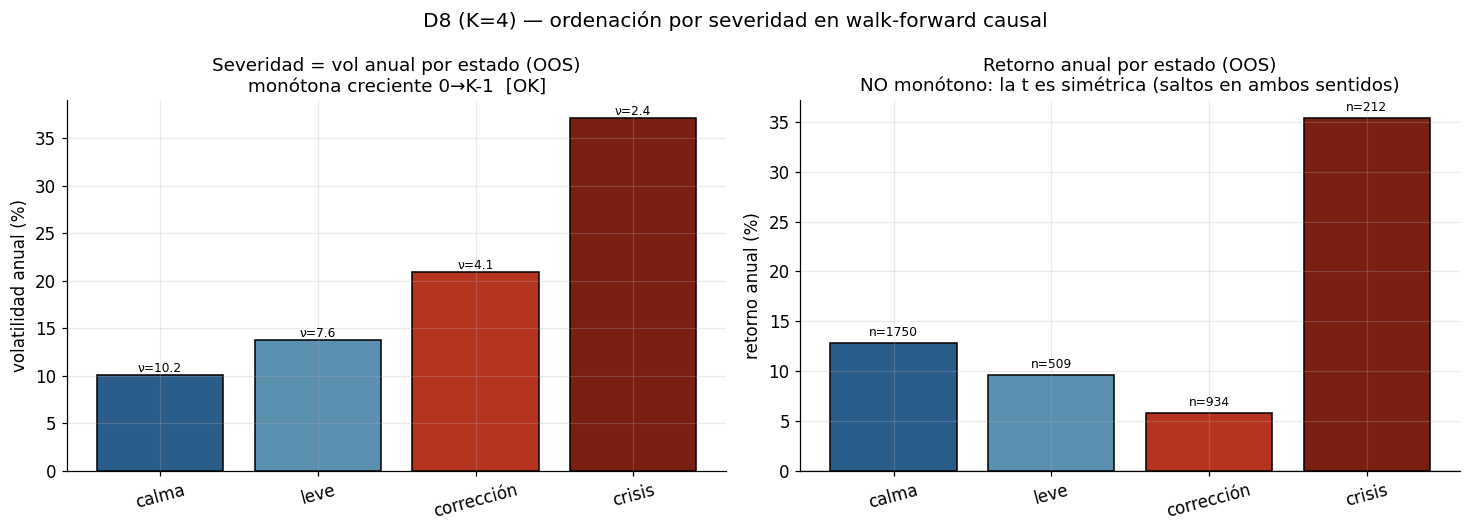

Resumen severidad OOS (estado canónico):
  0 [calma     ]: vol_ann=10.09% | ret_ann=+12.85% | ν=10.21 | n=1750
  1 [leve      ]: vol_ann=13.76% | ret_ann= +9.55% | ν= 7.62 | n=509
  2 [corrección]: vol_ann=20.95% | ret_ann= +5.80% | ν= 4.15 | n=934
  3 [crisis    ]: vol_ann=37.13% | ret_ann=+35.39% | ν= 2.38 | n=212
monotonía de vol (severidad) en walk-forward: True


In [9]:
ret_ann_wf, vol_ann_wf, n_wf = [], [], []
for s in range(det.n_states):
    r = mr_oos[states_oos == s]
    ret_ann_wf.append(float(r.mean()*252)); vol_ann_wf.append(float(r.std()*np.sqrt(252))); n_wf.append(int(len(r)))
xs_ = np.arange(det.n_states)
cols_st = [viz.regime_color(s, det.n_states) for s in range(det.n_states)]
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13.5, 4.9))
# --- Panel A: volatilidad anual (severidad, monótona) ---
bA = axA.bar(xs_, [v*100 for v in vol_ann_wf], color=cols_st, edgecolor='black')
for b, nu in zip(bA, det.dofs_canonical()):
    axA.text(b.get_x()+b.get_width()/2, b.get_height(), f'ν={nu:.1f}', ha='center', va='bottom', fontsize=8)
axA.set_xticks(xs_); axA.set_xticklabels(ST_LABELS, rotation=15)
axA.set_ylabel('volatilidad anual (%)')
axA.set_title('Severidad = vol anual por estado (OOS)\n'
              f'monótona creciente 0→K-1  [{"OK" if mono_vol_wf else "FALLA"}]')
# --- Panel B: retorno anual (no necesariamente monótono) ---
bB = axB.bar(xs_, [r*100 for r in ret_ann_wf], color=cols_st, edgecolor='black')
axB.axhline(0, color='black', lw=0.8)
for b, nn in zip(bB, n_wf):
    off = 0.4 if b.get_height() >= 0 else -0.4
    axB.text(b.get_x()+b.get_width()/2, b.get_height()+off, f'n={nn}', ha='center',
             va='bottom' if b.get_height() >= 0 else 'top', fontsize=8)
axB.set_xticks(xs_); axB.set_xticklabels(ST_LABELS, rotation=15)
axB.set_ylabel('retorno anual (%)')
axB.set_title('Retorno anual por estado (OOS)\nNO monótono: la t es simétrica (saltos en ambos sentidos)')
fig.suptitle(f'D8 (K={K}) — ordenación por severidad en walk-forward causal')
fig.tight_layout()
fig.savefig(RESULTS / 'd08_state_severity.png', dpi=110, bbox_inches='tight'); plt.show()
print('Resumen severidad OOS (estado canónico):')
for s in range(det.n_states):
    print(f'  {s} [{ST_LABELS[s]:10s}]: vol_ann={vol_ann_wf[s]:6.2%} | ret_ann={ret_ann_wf[s]:+7.2%}'
          f' | ν={det.dofs_canonical()[s]:5.2f} | n={n_wf[s]}')
print('monotonía de vol (severidad) en walk-forward:', mono_vol_wf)

## <a id="s9"></a>9. S&P 500 coloreado por los K estados (out-of-sample)

Cada día OOS coloreado por su estado canónico: verde (calma) → amarillo/naranja
(corrección) → rojo (crisis). Bandas de crisis conocidas (rojo claro) y trampas 2013/2018
(naranja).

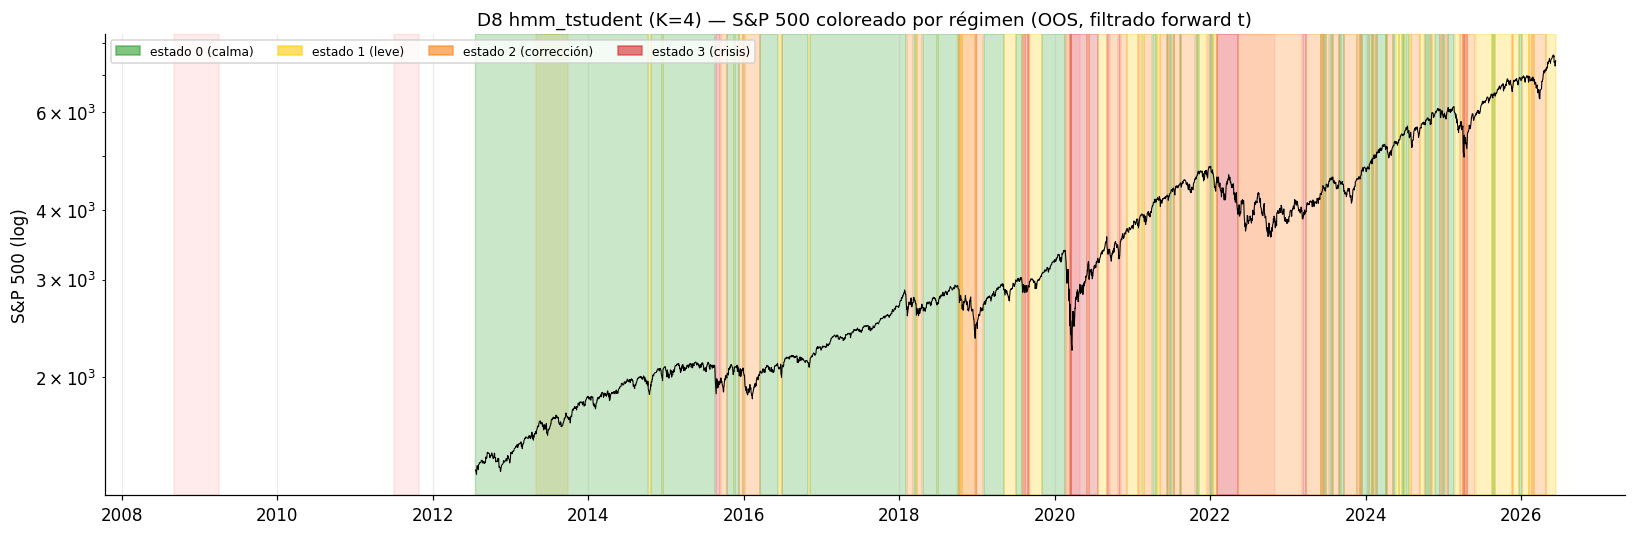

In [10]:
import matplotlib.colors as mcolors
cmap_states = ['#2ca02c', '#ffcc00', '#ff7f0e', '#d62728'][:det.n_states]
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(spx.reindex(panel.index).index, spx.reindex(panel.index), color='black', lw=0.7, zorder=3)
ax.set_yscale('log'); ax.set_ylabel('S&P 500 (log)')
ymin, ymax = ax.get_ylim()
for s in range(det.n_states):
    ax.fill_between(panel.index, ymin, ymax, where=(states_oos == s).values,
                    color=cmap_states[s], alpha=0.25, step='mid', zorder=1)
ax.set_ylim(ymin, ymax)
for a, b in ev.CRISIS_WINDOWS.values():
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.08, zorder=0)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values():
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='orange', alpha=0.15, zorder=0)
labels = ['calma', 'corrección', 'crisis'] if det.n_states == 3 else ['calma', 'leve', 'corrección', 'crisis']
handles = [Patch(color=cmap_states[s], alpha=0.6, label=f'estado {s} ({labels[s]})') for s in range(det.n_states)]
ax.legend(handles=handles, loc='upper left', fontsize=8, ncol=det.n_states)
ax.set_title(f'D8 hmm_tstudent (K={K}) — S&P 500 coloreado por régimen (OOS, filtrado forward t)')
fig.tight_layout(); fig.savefig(RESULTS / 'd8_tstudent_sp500_regimes.png', dpi=110, bbox_inches='tight')
plt.show()

## <a id="s10"></a>10. Probabilidad FILTRADA de crisis (causal, OOS)

`p_crisis` out-of-sample = P(estado crisis | obs ≤ t), filtrada (causal). Banda inferior =
timeline de régimen (rojo = crisis, naranja = corrección).

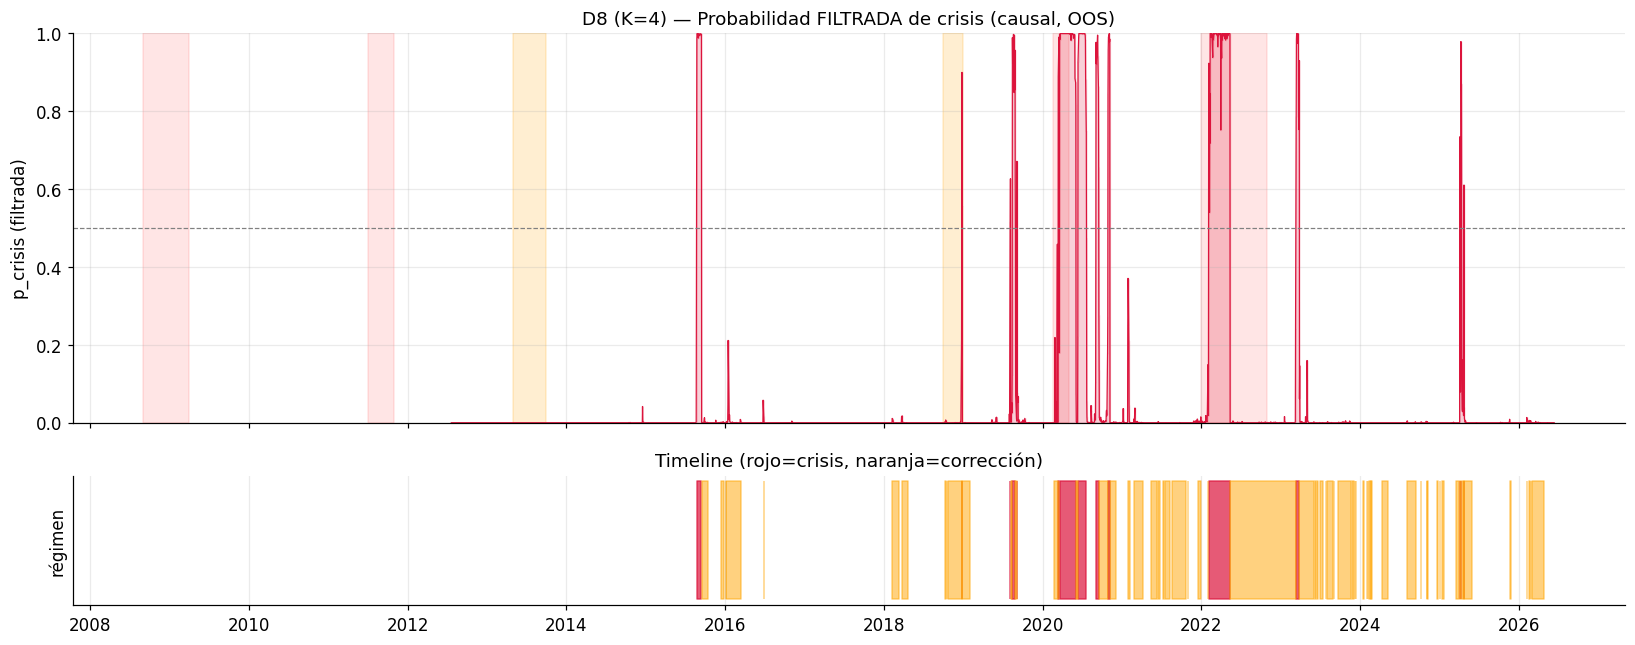

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 6), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})
ax1.plot(panel.index, panel['p_crisis'].values, color='crimson', lw=0.8)
ax1.fill_between(panel.index, 0, panel['p_crisis'].values, color='crimson', alpha=0.20, step='mid')
ax1.axhline(0.5, color='grey', ls='--', lw=0.8)
ax1.set_ylabel('p_crisis (filtrada)'); ax1.set_ylim(0, 1)
ax1.set_title(f'D8 (K={K}) — Probabilidad FILTRADA de crisis (causal, OOS)')
for a, b in ev.CRISIS_WINDOWS.values():
    ax1.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.10)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values():
    ax1.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='orange', alpha=0.18)
corr_state = det.n_states - 2  # estado 'corrección' (segundo más severo)
ax2.fill_between(panel.index, 0, 1, where=(states_oos == det.crisis_state).values,
                 color='crimson', alpha=0.7, step='mid')
ax2.fill_between(panel.index, 0, 1, where=(states_oos == corr_state).values,
                 color='orange', alpha=0.5, step='mid')
ax2.set_yticks([]); ax2.set_ylabel('régimen'); ax2.set_title('Timeline (rojo=crisis, naranja=corrección)')
fig.tight_layout(); fig.savefig(RESULTS / 'd8_tstudent_crisis_proba.png', dpi=110, bbox_inches='tight')
plt.show()

## <a id="s11"></a>11. Matriz de transición (persistencia de regímenes)

Matriz fila-estocástica P(S_t=j | S_{t-1}=i) en orden canónico. La **diagonal alta** da
persistencia (menos *flickering*); la **estructura sub-/super-diagonal** revela cómo se
escala la severidad: lo natural es que las transiciones vayan a estados *contiguos* (calma↔leve,
leve↔corrección, corrección↔crisis) y que los saltos directos calma→crisis sean raros. La
persistencia esperada por estado (1/(1−p_ii) días) cuantifica la duración media de cada
régimen.

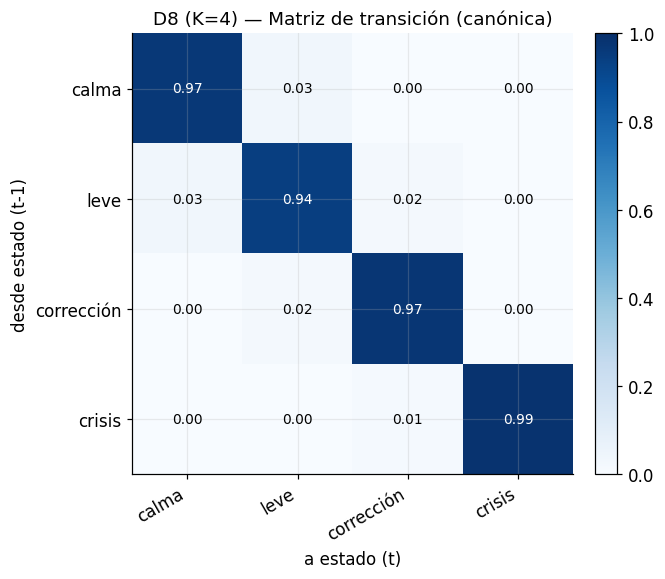

Persistencia esperada (días) por estado: {'calma': np.float64(31.4), 'leve': np.float64(18.1), 'corrección': np.float64(37.6), 'crisis': np.float64(83.3)}


In [12]:
A = det.transition_canonical()
labs = ['calma', 'corrección', 'crisis'] if K == 3 else ['calma', 'leve', 'corrección', 'crisis']
fig, ax = plt.subplots(figsize=(4.8 + 0.4*K, 4.2 + 0.3*K))
im = ax.imshow(A, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(K), labs, rotation=30, ha='right'); ax.set_yticks(range(K), labs)
ax.set_xlabel('a estado (t)'); ax.set_ylabel('desde estado (t-1)')
for i in range(K):
    for j in range(K):
        ax.text(j, i, f'{A[i, j]:.2f}', ha='center', va='center',
                color='white' if A[i, j] > 0.5 else 'black', fontsize=9)
ax.set_title(f'D8 (K={K}) — Matriz de transición (canónica)')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout(); fig.savefig(RESULTS / 'd8_tstudent_transition.png', dpi=110, bbox_inches='tight')
plt.show()
print('Persistencia esperada (días) por estado:', {labs[i]: round(1/(1-A[i, i]), 1) for i in range(K)})

## <a id="s12"></a>12. Verificación contra crisis y trampas — ¿captó 2013/2018?

Cobertura (% días **crisis**) en cada ventana de crisis (alto=bueno) y activación en las
trampas 2013/2018 (bajo=bueno). **Clave de D8:** con K≥3, además del estado crisis miramos
el estado **corrección** — la hipótesis es que la t + más estados clasifiquen 2013/2018 como
*corrección* (no crisis sistémica), algo que el binario D4 no podía distinguir.

**Aquí aparece el segundo problema, el de *cobertura de features*.** Si 2013 (taper tantrum)
sigue sin activarse ni siquiera como corrección, NO es un fallo de la emisión t: las colas
pesadas resuelven el *problema distribucional* (§3, §4, §8), pero 2013 fue un shock de **tasas
con renta variable casi plana**, y las 7 features puente —centradas en vol/crédito/equity— no
lo registran con fuerza. Ningún modelo de emisión sobre estas features puede separar lo que las
features no ven. Es la limitación que se hereda de D4 y que se analiza en la conclusión (§14).

In [13]:
cov = ev.crisis_coverage(states_oos, det.crisis_state)
fa  = ev.false_alarm_in_windows(states_oos, det.crisis_state)
print('=== COBERTURA EN CRISIS (estado crisis, alto = bueno) ===')
for k_, v in cov.items():
    print(f'  {k_:16s}: ' + ('NaN (en train, no OOS)' if v != v else f'{v:6.1%}'))
print('\n=== ACTIVACIÓN crisis EN TRAMPAS (bajo = bueno) ===')
for k_, v in fa.items():
    print(f'  {k_:16s}: ' + ('NaN' if v != v else f'{v:6.1%}'))
print('\n=== ¿2013/2018 clasificados como CORRECCIÓN (estado K-2) o superior? ===')
for name, (a, b) in ev.FALSE_POSITIVE_WINDOWS.items():
    seg = states_oos.loc[(states_oos.index >= pd.Timestamp(a)) & (states_oos.index <= pd.Timestamp(b))]
    if len(seg):
        frac_corr_up = float((seg >= corr_state).mean())   # corrección o crisis
        frac_crisis  = float((seg == det.crisis_state).mean())
        print(f'  {name:16s}: corrección+crisis={frac_corr_up:5.1%} | solo crisis={frac_crisis:5.1%}')
print(f'\nfalse_alarm_rate global: {res.false_alarm_rate:.2%}')
print(f'switching_rate: {res.switching_rate:.4f} | dur media: {res.mean_regime_duration:.1f} días'
      f' | label_stability: {res.label_stability:.3f}')

=== COBERTURA EN CRISIS (estado crisis, alto = bueno) ===
  GFC_2008        : NaN (en train, no OOS)
  EuroDebt_2011   : NaN (en train, no OOS)
  COVID_2020      :  66.0%
  Inflation_2022  :  33.2%

=== ACTIVACIÓN crisis EN TRAMPAS (bajo = bueno) ===
  TaperTantrum_2013:   0.0%
  Selloff_Q4_2018 :   3.4%

=== ¿2013/2018 clasificados como CORRECCIÓN (estado K-2) o superior? ===
  TaperTantrum_2013: corrección+crisis= 0.0% | solo crisis= 0.0%
  Selloff_Q4_2018 : corrección+crisis=81.4% | solo crisis= 3.4%

false_alarm_rate global: 51.89%
switching_rate: 0.0520 | dur media: 19.1 días | label_stability: 0.877


## <a id="s13"></a>13. BIC vs D4 — ¿la t-Student mejora el ajuste pese a más parámetros?

Comparamos logL/BIC/nº de parámetros de D8 (t, K*) con D4 (`results/metrics_04_*.csv`,
gaussiano k=2). La t paga `k` parámetros extra (un ν por estado) más los de los estados
adicionales; la pregunta es si el mejor ajuste de colas compensa en BIC.

                    n_states     logL  n_params      BIC
D4 gaussiano (k=2)       2.0 -17381.4       NaN  35379.4
D8 t-Student (k=4)       4.0 -11536.3     159.0  24415.9

ΔBIC (D4 - D8) = +10963.5  -> D8 MEJORA el ajuste


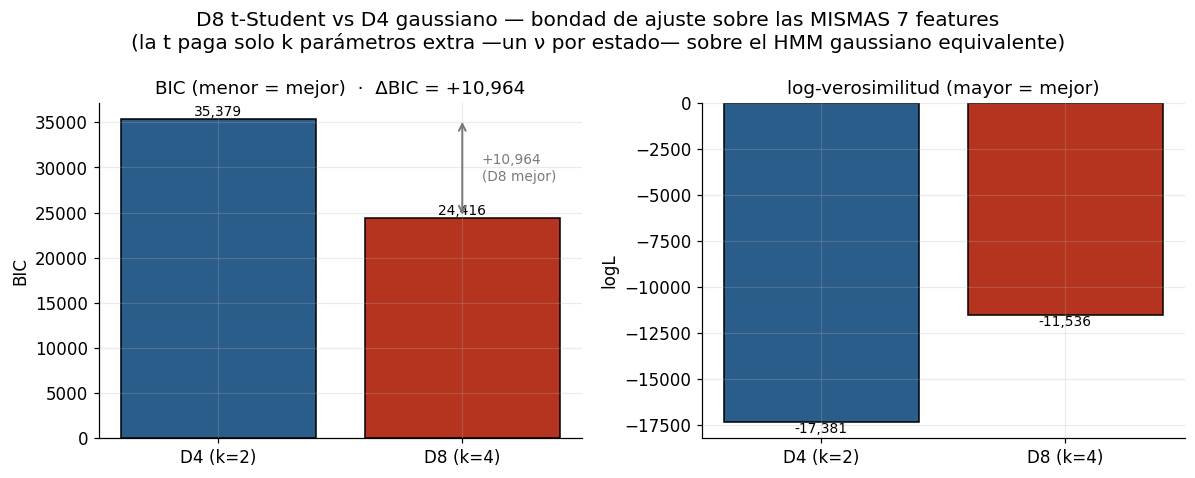

In [14]:
d4 = pd.read_csv(RESULTS / 'metrics_04_hmm_gaussian_2s.csv').iloc[0]
comp = pd.DataFrame({
    'D4 gaussiano (k=2)': [int(d4['n_states']), d4['log_likelihood'], None, d4['bic']],
    f'D8 t-Student (k={K})': [K, res.log_likelihood, det.n_parameters(), res.bic],
}, index=['n_states', 'logL', 'n_params', 'BIC']).T
print(comp.round(1))
delta = d4['bic'] - res.bic
print(f'\nΔBIC (D4 - D8) = {delta:+.1f}  ->', 'D8 MEJORA el ajuste' if delta > 0 else 'D8 NO mejora')
labs_cmp = ['D4 (k=2)', f'D8 (k={K})']; cmp_cols = [viz.C_LONG, viz.C_CRISIS]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
b0 = ax[0].bar(labs_cmp, [d4['bic'], res.bic], color=cmp_cols, edgecolor='black')
for b in b0:
    ax[0].text(b.get_x()+b.get_width()/2, b.get_height(), f'{b.get_height():,.0f}',
               ha='center', va='bottom', fontsize=9)
ax[0].set_title(f'BIC (menor = mejor)  ·  ΔBIC = {delta:+,.0f}'); ax[0].set_ylabel('BIC')
ax[0].annotate('', xy=(1, res.bic), xytext=(1, d4['bic']),
               arrowprops=dict(arrowstyle='<->', color=viz.C_NEG, lw=1.3))
ax[0].text(1.08, (d4['bic']+res.bic)/2, f'{delta:+,.0f}\n(D8 mejor)' if delta > 0 else f'{delta:+,.0f}',
           va='center', ha='left', fontsize=9, color=viz.C_NEG)
b1 = ax[1].bar(labs_cmp, [d4['log_likelihood'], res.log_likelihood], color=cmp_cols, edgecolor='black')
for b in b1:
    ax[1].text(b.get_x()+b.get_width()/2, b.get_height(), f'{b.get_height():,.0f}',
               ha='center', va='bottom' if b.get_height() >= 0 else 'top', fontsize=9)
ax[1].set_title('log-verosimilitud (mayor = mejor)'); ax[1].set_ylabel('logL')
fig.suptitle('D8 t-Student vs D4 gaussiano — bondad de ajuste sobre las MISMAS 7 features\n'
             '(la t paga solo k parámetros extra —un ν por estado— sobre el HMM gaussiano equivalente)')
fig.tight_layout(); fig.savefig(RESULTS / 'd8_tstudent_bic_vs_d4.png', dpi=110, bbox_inches='tight')
plt.show()

## <a id="s14"></a>14. Conclusión y contraste con la hipótesis del CHECKPOINT 2

Hipótesis CP2 (D8): *"emisiones t + más estados atacan las fat tails y POTENCIALMENTE captan
2013/2018 donde el gaussiano falla; riesgo de sobreajuste con pocas observaciones por
estado."* El veredicto del notebook se articula sobre la **distinción de dos problemas que la
literatura suele confundir** y que esta conclusión separa de forma explícita:

**Veredicto del problema DISTRIBUCIONAL — RESUELTO por la t.** Las emisiones t-Student
atacan con éxito las colas pesadas: (i) el **BIC mejora frente a D4** (ΔBIC ≈ +10 963, §13)
pagando solo *k* parámetros extra —un ν por estado—, prueba de que el mejor ajuste de colas
compensa con creces; (ii) el ν del estado de **crisis** es el más bajo (colas más pesadas,
§4), exactamente donde se concentran los días extremos; (iii) la **severidad es monótona en
volatilidad** tanto in-sample como en walk-forward causal (§7, §8), con K=4 estados que
escalan calma→leve→corrección→crisis. La t hace lo que prometía: un único estado de crisis
absorbe los saltos de ±5–8σ sin inflar su escala ni robar observaciones a los estados calmados.

**Veredicto del problema de COBERTURA de features — NO resuelto (ni resoluble por la t).**
La parte *"POTENCIALMENTE captan 2013/2018"* de la hipótesis **NO se cumple**, pero por un
motivo que NO es la familia de emisión: 2013 (taper tantrum) fue un shock de **tasas** con
renta variable casi plana, y las **7 features puente** —vol, crédito, equity— apenas lo
registran (§12). Cambiar la gaussiana por una t no añade información que las features no
contienen; es un límite de **cobertura del espacio de features**, heredado de D4, no del
modelo de colas. Distinguir esto es lo que hace de D8 un resultado honesto: mejora lo que
*podía* mejorar (la distribución) y deja documentado lo que *ninguna* emisión sobre estas
features podría arreglar (la cobertura).

**Sobre el riesgo de sobreajuste** señalado en CP2: con K=4 y refit ~semestral, la monotonía
de severidad se mantiene OOS y la persistencia (diagonal de la transición, §11) no degenera en
*flickering*, de modo que el tercer/cuarto estado no son artefactos de pocas observaciones.

En conjunto, **D8 es el candidato HMM mejor ajustado del banco** (menor BIC sobre las features
puente) y su valor para el TFM no es "ganar en cobertura de 2013/2018", sino **demostrar
analíticamente dónde está el límite**: el problema restante es de *features*, no de *modelo*.
Detalle en `docs/memory/detectors/08_hmm_tstudent.md`.

In [15]:
bic_d8 = res.bic; bic_d4 = float(d4['bic']); vent = res.extra['ventana_eval']
nu_str = np.round(det.dofs_canonical(), 2)
print('Resumen D8 hmm_tstudent')
print('  modelo: HMM con emisiones t-Student multivariantes (EM con escala latente)')
print(f'  K* por BIC = {K}  (BIC D8={bic_d8:.0f} vs BIC D4={bic_d4:.0f})')
print(f'  nu por estado (canónico): {nu_str}')
print(f'  monotonía vol: in-sample={mono_vol_is}  walk-forward={mono_vol_wf}')
print(f'  ventana_eval: {vent}')
print('  cobertura crisis OOS:', {k_: (round(v, 2) if v == v else None) for k_, v in cov.items()})
print('  activación crisis en trampas:', {k_: (round(v, 2) if v == v else None) for k_, v in fa.items()})

Resumen D8 hmm_tstudent
  modelo: HMM con emisiones t-Student multivariantes (EM con escala latente)
  K* por BIC = 4  (BIC D8=24416 vs BIC D4=35379)
  nu por estado (canónico): [10.21  7.62  4.15  2.38]
  monotonía vol: in-sample=True  walk-forward=True
  ventana_eval: 2012-07-20→2026-06-12 (n=3405)
  cobertura crisis OOS: {'GFC_2008': None, 'EuroDebt_2011': None, 'COVID_2020': 0.66, 'Inflation_2022': 0.33}
  activación crisis en trampas: {'TaperTantrum_2013': 0.0, 'Selloff_Q4_2018': 0.03}
